#### Import required packages

In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


#### Import sample data and drop uneccessary columns

In [2]:
data_for_model = pd.read_pickle("data/abc_regression_modelling.p")
data_for_model.drop("customer_id", axis = 1, inplace = True)
print(data_for_model.columns)

Index(['distance_from_store', 'gender', 'credit_score',
       'customer_loyalty_score', 'total_sales', 'total_items',
       'transaction_count', 'product_area_count', 'average_basket_value'],
      dtype='object')


#### Shuffle Data

In [3]:
data_for_model = shuffle(data_for_model, random_state = 42)

#### Dealing with missing values|

In [4]:
data_for_model.isna().sum()
data_for_model.dropna(how = "any", inplace = True)

#### Split Input variables and Output variables

In [5]:
X = data_for_model.drop(["customer_loyalty_score"], axis = 1)
y = data_for_model["customer_loyalty_score"]

#### Split out training and test sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#### Dealing with categorical variables

In [7]:
categorical_vars = ["gender"]

one_hot_encoder = OneHotEncoder(sparse_output = False, drop = "first")

X_train_encoded = one_hot_encoder.fit_transform(X_train[categorical_vars])
X_test_encoded = one_hot_encoder.transform(X_test[categorical_vars])

encoder_feature_names = one_hot_encoder.get_feature_names_out(categorical_vars)

X_train_encoded = pd.DataFrame(X_train_encoded, columns = encoder_feature_names)
X_train = pd.concat([X_train.reset_index(drop = True), X_train_encoded.reset_index(drop = True)], axis = 1)
X_train.drop(categorical_vars, axis = 1, inplace = True)

X_test_encoded = pd.DataFrame(X_test_encoded, columns = encoder_feature_names)
X_test = pd.concat([X_test.reset_index(drop = True), X_test_encoded.reset_index(drop = True)], axis = 1)
X_test.drop(categorical_vars, axis = 1, inplace = True)

In [8]:
print(X_train)

     distance_from_store  credit_score  total_sales  total_items  \
0                   0.04          0.67      1191.53          216   
1                   2.04          0.64      1581.41          343   
2                   2.24          0.63      1327.51          266   
3                   1.72          0.59      2094.10          352   
4                   0.24          0.53      1133.45          180   
..                   ...           ...          ...          ...   
310                 0.37          0.61      1397.66          270   
311                 2.94          0.62      2397.63          282   
312                 2.31          0.53      1805.39          298   
313                 2.80          0.41      1524.01          278   
314                 4.47          0.74      3770.71          415   

     transaction_count  product_area_count  average_basket_value  gender_M  
0                   53                   5             22.481698       1.0  
1                   41       

#### Model Training

In [19]:
regressor = DecisionTreeRegressor(random_state = 42, max_depth = 4)
regressor.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### Model Assessment

#### Predict on the test set

In [20]:
y_pred = regressor.predict(X_test)

#### Calculate R-squared

In [21]:
r_squared = r2_score(y_test, y_pred)
print(r_squared)

0.8666832224200037


#### Cross validation

In [12]:
cv = KFold(n_splits = 4, shuffle = True, random_state = 42)
cv_scores = cross_val_score(regressor, X_train, y_train, cv =cv, scoring = "r2")
cv_scores.mean()

np.float64(0.8760266035577694)

#### Calculate adjusted R-squared

In [13]:
num_data_points, num_input_vars = X_test.shape
adjusted_r_squared = 1 - (1 - r_squared) * (num_data_points - 1) / (num_data_points - num_input_vars -1)
print(adjusted_r_squared)

0.8865440644217988


#### A demonstration of overfitting

In [14]:
y_pred_training = regressor.predict(X_train)
r2_score(y_train, y_pred_training)

1.0

#### Finding the best max depth

In [17]:
max_depth_list = list(range(1,9))

accuracy_scores = []

for depth in max_depth_list:
    
    regressor = DecisionTreeRegressor(max_depth = depth, random_state = 42)
    regressor.fit(X_train, y_train)
    y_pred = regressor.predict(X_test)
    accuracy = r2_score(y_test,y_pred)
    accuracy_scores.append(accuracy)

max_accuracy = max(accuracy_scores)
max_accuracy_idx = accuracy_scores.index(max_accuracy)
optimal_depth = max_depth_list[max_accuracy_idx]
print(optimal_depth)

7


#### Plot of max depths

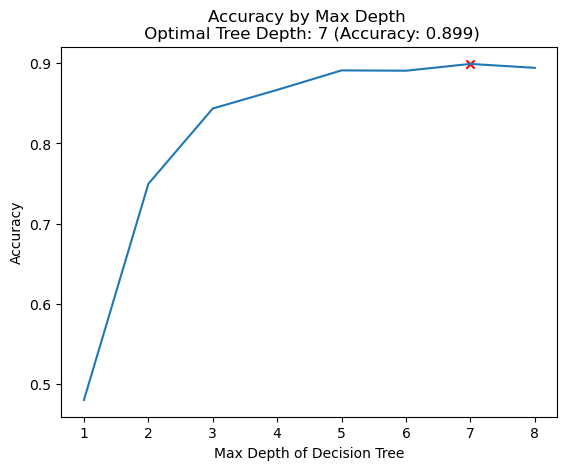

In [18]:
plt.plot(max_depth_list,accuracy_scores)
plt.scatter(optimal_depth,max_accuracy,marker = "x", color = "red")
plt.title(f"Accuracy by Max Depth \n Optimal Tree Depth: {optimal_depth} (Accuracy: {round(max_accuracy,4)})")
plt.xlabel("Max Depth of Decision Tree")
plt.ylabel("Accuracy")
plt.tight_layout
plt.show()

#### Plot our model

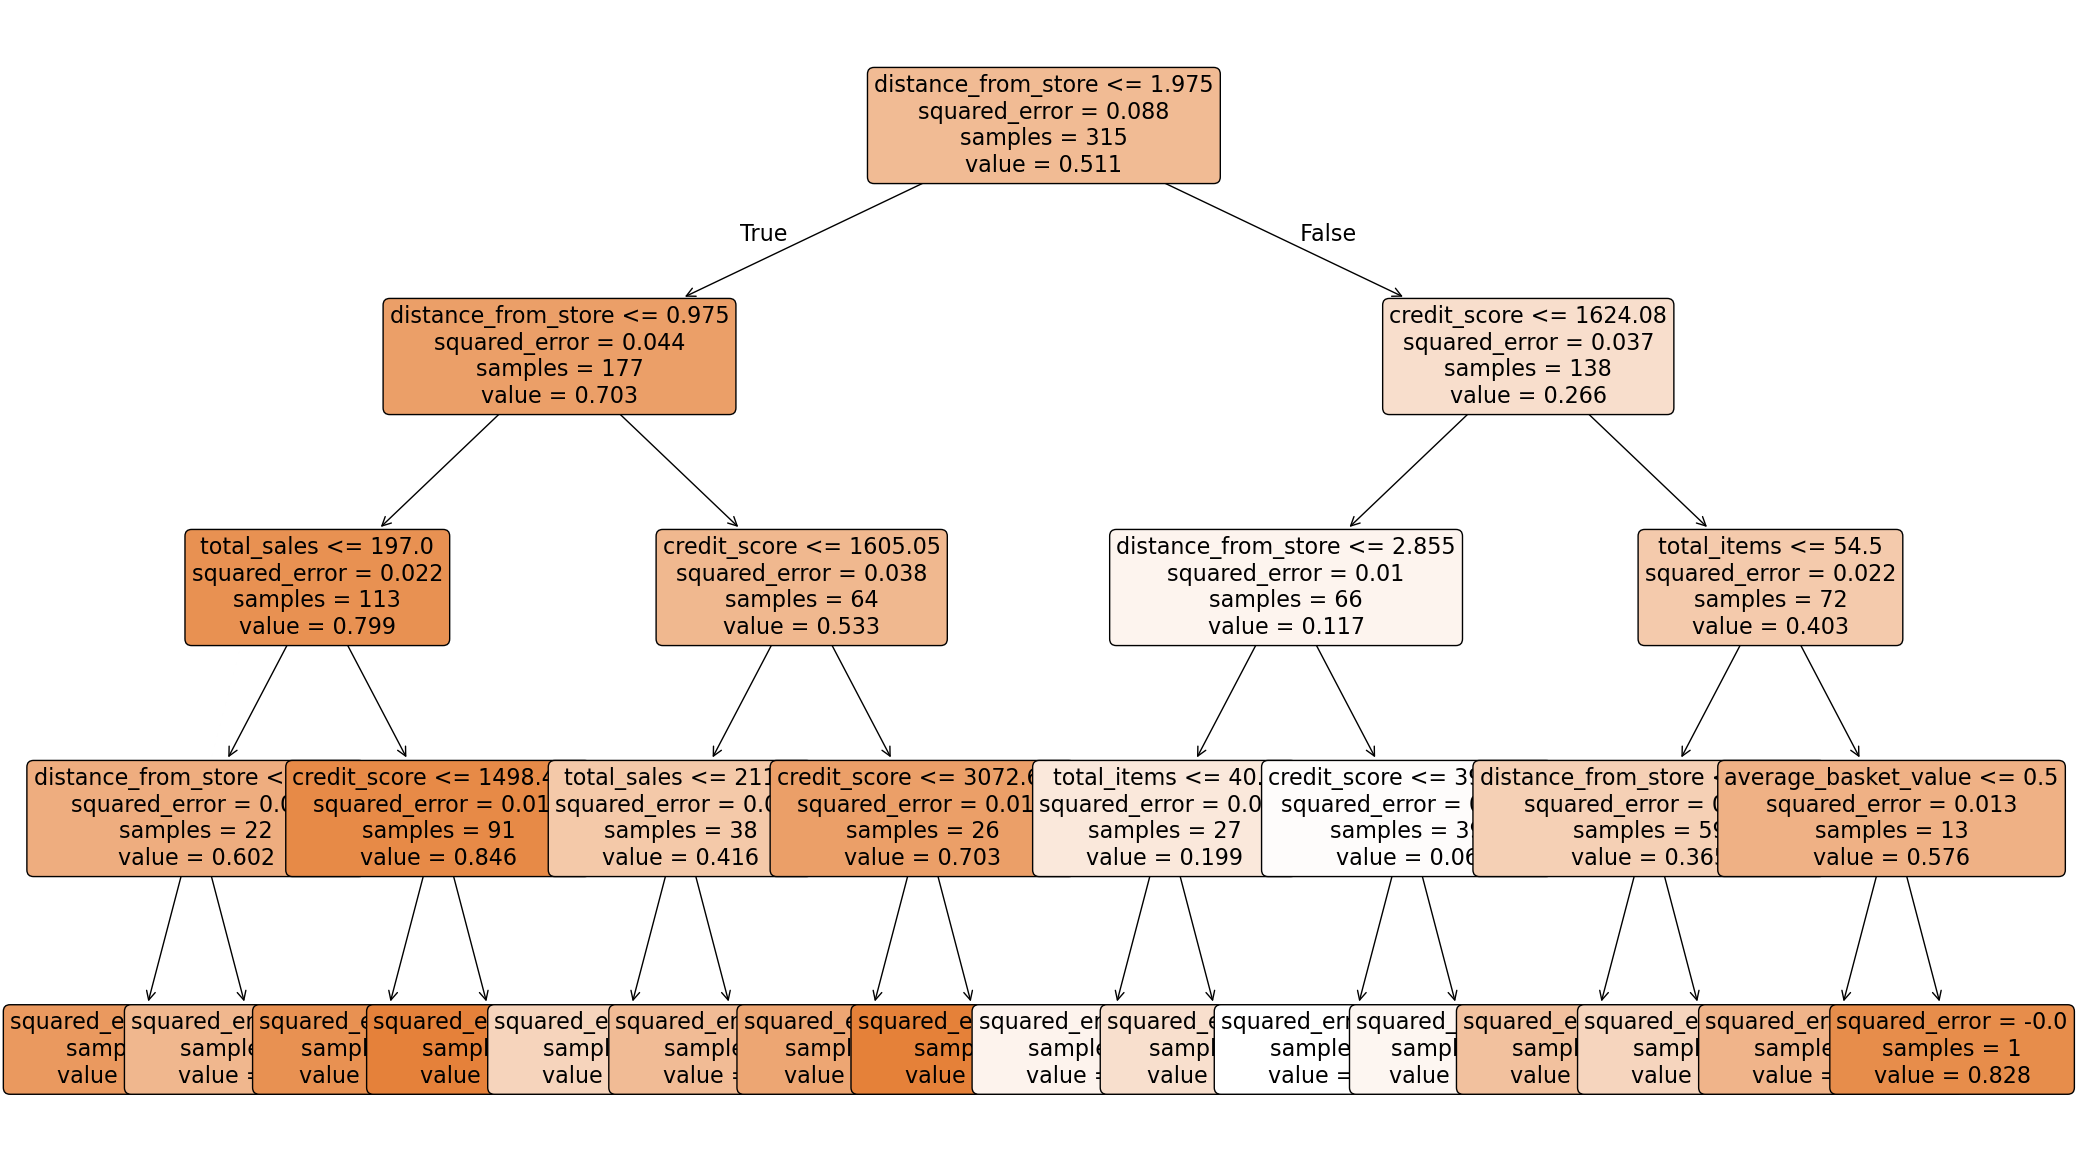

In [22]:
plt.figure(figsize=(25,15))
tree = plot_tree(regressor,
                feature_names = X.columns,
                filled = True,
                rounded = True,
                fontsize = 16)